In [3]:
import pandas as pd 
import numpy as np 
from datetime import datetime 
import matplotlib.pyplot as plt 
import os 

In [4]:
drivers = pd.read_csv("/Users/maivo/Documents/GitHub/qtm151fall2025/1-Formula_One/drivers.csv")
results = pd.read_csv("/Users/maivo/Documents/GitHub/qtm151fall2025/1-Formula_One/results.csv")
constructors = pd.read_csv("/Users/maivo/Documents/GitHub/qtm151fall2025/1-Formula_One/constructors.csv")
races = pd.read_csv("/Users/maivo/Documents/GitHub/qtm151fall2025/1-Formula_One/races.csv")
status = pd.read_csv("/Users/maivo/Documents/GitHub/qtm151fall2025/1-Formula_One/status.csv")


In [5]:
df = results.merge(races[["raceId", "year", "date"]], on="raceId", how="left")

df = df.merge(
    drivers[["driverId", "forename", "surname", "dob", "nationality"]],
    on="driverId", how="left"
)

df = df.merge(
    constructors[["constructorId", "name", "nationality"]]
    .rename(columns={"name":"constructor_name"}),
    on="constructorId", how="left"
)

df = df.merge(status, on="statusId", how="left")

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['dob']  = pd.to_datetime(df['dob'],  errors='coerce')

df["points"] = pd.to_numeric(df["points"], errors="coerce")
df["grid"] = pd.to_numeric(df["grid"], errors="coerce")
df["position"] = pd.to_numeric(df["position"], errors="coerce")
df["fastestLapSpeed"] = pd.to_numeric(df["fastestLapSpeed"], errors="coerce")

df["finished"] = df["status"].str.contains("Finished|Lap", case=False, na=False)

df["age_at_race"] = (df["date"] - df["dob"]).dt.days / 365.25

df_clean = df[[
    "raceId", "year", "date",
    "driverId", "forename", "surname", "age_at_race",
    "constructorId", "constructor_name",
    "grid", "position", "points",
    "fastestLapSpeed",
    "status", "finished"
]]

In [6]:
df_clean = df_clean[df_clean["year"] >= 1990]
df_clean["podium"] = df_clean["position"] <= 3

season_df = (
    df_clean
    .groupby(["driverId", "forename", "surname", "year"], as_index=False)
    .agg(
        season_points=("points", "sum"),
        avg_age=("age_at_race", "mean"),
        avg_fastest_lap=("fastestLapSpeed", "mean"),
        avg_finish_position=("position", "mean"),
        finish_rate=("finished", "mean"),
        avg_grid_position=("grid", "mean"),
        podium_count=("podium", "sum") 
    )
)

print(season_df.head())

   driverId forename   surname  year  season_points    avg_age  \
0         1    Lewis  Hamilton  2007          109.0  22.507066   
1         1    Lewis  Hamilton  2008           98.0  23.510533   
2         1    Lewis  Hamilton  2009           49.0  24.510368   
3         1    Lewis  Hamilton  2010          240.0  25.513887   
4         1    Lewis  Hamilton  2011          227.0  26.547786   

   avg_fastest_lap  avg_finish_position  finish_rate  avg_grid_position  \
0       207.627941             3.000000     0.941176           2.588235   
1       204.564667             4.411765     0.944444           3.888889   
2       201.310250             7.642857     0.764706           9.176471   
3       200.167389             3.750000     0.789474           5.157895   
4       198.009053             3.750000     0.842105           3.578947   

   podium_count  
0            12  
1            10  
2             5  
3             9  
4             6  


## <span style="color:blue"> IV. Results </span>


<font size = "4">


To investigate the factors contributed to Formula One success, a seasonal-level dataset was constructed for driver performance from 1990 onwards. For to every driver season, total season points were calculated as the response measure of success across 6 explanatory variables:

- Finishing consistency (finish rate)
- Average age during the season
- Average fastest lap speed
- Average finishing position
- Average grid (starting) position
- Podium count (number of top-3-finishes)

Scatterpots and boxplots were then used to examine the relationship between each explanatory variable and seasonal points.

<font size = "4">


**1. Finishing Consistency and Season Points:**


Drivers were categorized into 3 groups summarizing their finishing consistency by finish rate (proportion of races finished):


- Low finish rate (0-50%)
- Medium finish rate (50-80%)
- High finish rate (80-100%)


<Figure size 800x500 with 0 Axes>

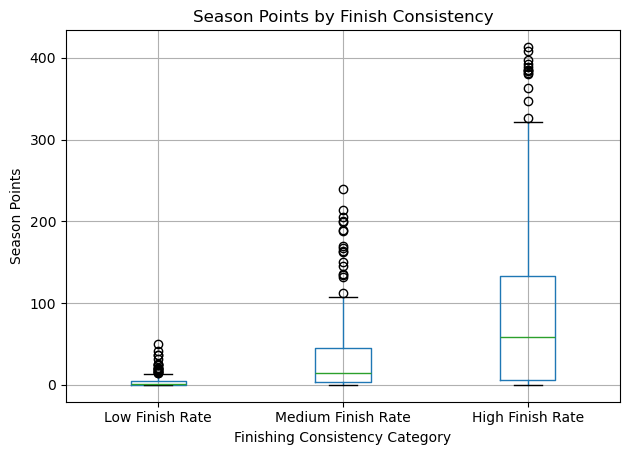

In [9]:
season_df["finish_cat"] = pd.cut(
    season_df["finish_rate"],
    bins=[0, 0.5, 0.8, 1.0],
    labels=["Low Finish Rate", "Medium Finish Rate", "High Finish Rate"]
)

plt.figure(figsize=(8,5))
season_df.boxplot(column="season_points", by="finish_cat")
plt.suptitle("")
plt.xlabel("Finishing Consistency Category")
plt.ylabel("Season Points")
plt.title("Season Points by Finish Consistency")
plt.tight_layout()
plt.show()

<font size = "4">


**Fig. 1. Boxplot of season points by Finish Consistency**


A clear correlation was observed, such that drivers with a higher finish rate generally had greater seasonal points, demonstrated the greatest median season points, and longer upper whiskers. On the other hand, drivers with low finish rates clustered close to the bottom of the points distrution, with many seasons scoring few to no points. 


Overall, this indicates that finishing in the race is crucial for driver success  and increases the chances in accumulating points within the season.



In [20]:
season_df[[
    "season_points", "avg_age", "avg_fastest_lap",
    "avg_finish_position", "finish_rate", "avg_grid_position", "podium_count"
]].describe()

,season_points,avg_age,avg_fastest_lap,avg_finish_position,finish_rate,avg_grid_position,podium_count
count,884.000000,884.000000,452.000000,842.000000,884.000000,884.000000,884.000000
mean,40.329186,28.679960,203.136566,9.052198,0.625683,11.838931,1.988688
std,72.470185,4.794910,8.310773,4.033629,0.258044,5.797946,3.757346
min,0.000000,17.816924,156.194000,1.200000,0.000000,0.000000,0.000000
25%,0.000000,24.996948,197.386219,6.000000,0.470588,7.446875,0.000000
50%,8.000000,28.183567,202.921557,9.166667,0.684211,11.818015,0.000000
75%,48.000000,31.996720,208.812952,11.820772,0.823529,16.203125,2.000000
max,413.000000,43.565503,235.177000,21.000000,1.000000,26.000000,18.000000


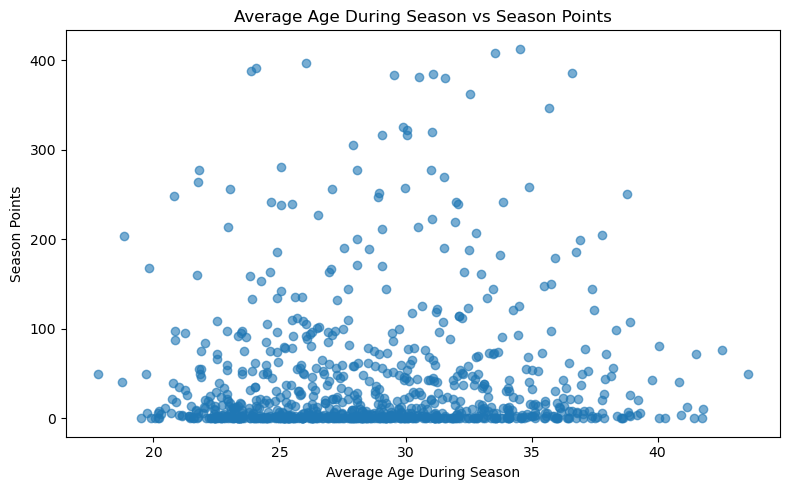

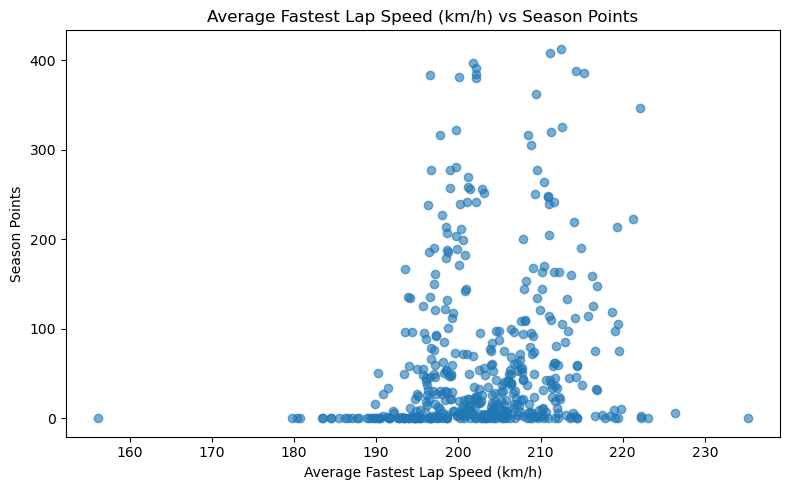

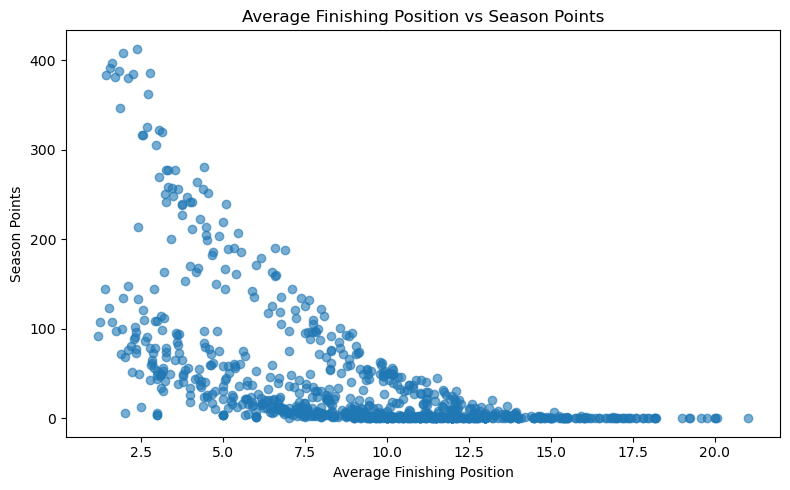

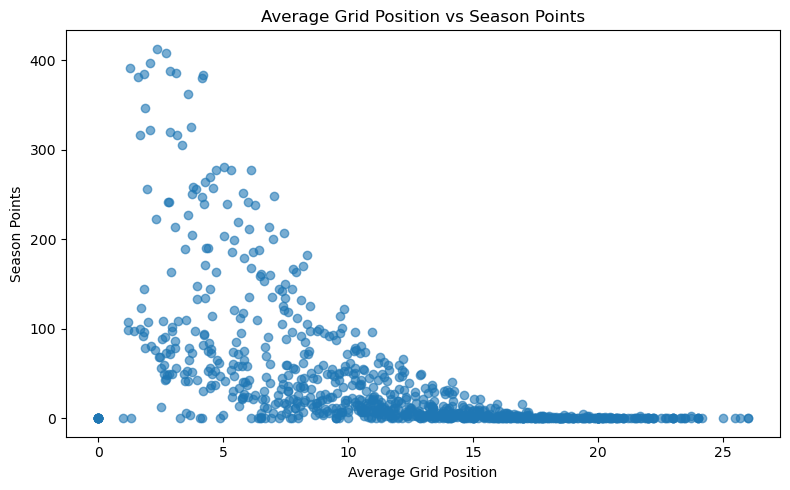

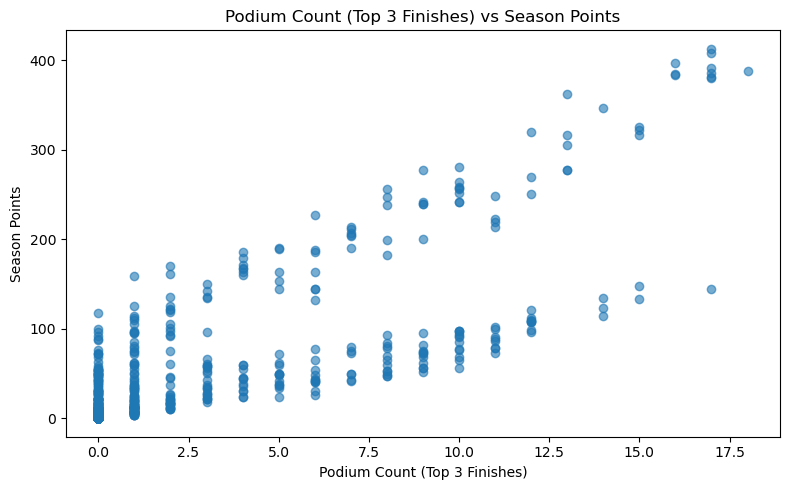

In [ ]:
def scatter_vs_points(df, x_col, x_label):
    plt.figure(figsize=(8,5))
    plt.scatter(df[x_col], df["season_points"], alpha=0.6)
    plt.xlabel(x_label)
    plt.ylabel("Season Points")
    plt.title(f"{x_label} vs Season Points")
    plt.tight_layout()
    plt.show()

cols_and_labels = [
    ("avg_age", "Average Age During Season"),
    ("avg_fastest_lap", "Average Fastest Lap Speed (km/h)"),
    ("avg_finish_position", "Average Finishing Position"),
    ("avg_grid_position", "Average Grid Position"),
    ("podium_count", "Podium Count (Top 3 Finishes)"),  
]

for col, label in cols_and_labels:
    scatter_vs_points(season_df, col, label)



<font size = "4">

**Fig. 2. Scatter plot of Average Age of driver during season and Season Points**

Overall, the scatter plot of average age vs. total season points demonstrated a weak linear relationship. Drivers, both younger and older appeared scattered across the full range of points. Thus, age seems to be a poor predictor of seasonal performance. 

**Fig. 3. Scatter plot of Average Fastest Lap Speed of driver and Season Points**

Compared to Average age, the scatterplot of Average Fastest Lap speed vs. season points also suggested a weak positive association. While drivers with higher average fastest-lap speeds tend to accumulate more points during the season, the data points are very dispersed: several drivers with similar fastest-lap speeds fluctuate vastly in their point totals. 

Overall, the pattern suggests that while fastest-lap speed could contribute to season driver success, it is not sufficient on it's own.

**Fig. 4. Scatter plot of Average Finishing Position and and Season Points**

A strong inverse relationship was demonstrated in the scatter plot of Average Finishinf Position vs. Season Points. Lower positions (1st, 2nd, 3rd) generally accumulated greater season points, meanwhile, drivers with higher positions on average rarely accumulated many points. 

This suggests average finishing position is a clear indicator of driver success, and intuitively this makes sense as finishing closer to the front more consistently yields greater points.   

**Fig. 5. Scatter plot of Average Grid Position and and Season Points**

This scatterplot also demonstrated a strong negative trend, wherein drivers starting closer to the front with lower grid position on average earned more season points than those with consistently high grid positions. This indicates the benefits of qualifying pace and starting near the front to potentially avoid race traffic and accidents that may slow the driver in completing the race.

**Fig. 6. Scatter plot of Podium Count (Top 3 Finishes) and Season Points**

According to the scatterplot, podium counts (number of top-3- finishes in a season) is also a good predictor of success, as shown by the strong linear trend observed. Drivers achieving greater podium titles generally had considerably higher season points compared to drivers with few to no podium titles. 

This also reflects how F-1 is scored, where podium positions earning the most points in a race. Therefore, consistently achieving the podium is an important predictor in F-1 driver success.

## <span style="color:blue"> V. Discussion </span>

<font size = "4">

In our analyses, using total season points to measure driver success, the most important factors contributing to success in F-1 racing is consistently high finish rate, strong finishing position, a grid position closer to the front from strong qualifying performance, and frequent podium finishes. Meanwhile, Age and Fastest Lap speed measures play a smaller role in predicting driver success. 

More specifically, podium count, average finishing position presented the strongest relationship with season points. This suggests that consistent ability to finish races near the top is a key indicator of driver success. The average grid position also strongly predicted season points. By qualifying for a good grid position, a driver can avoid the time loss due to difficult maneuvers and mishaps at the beginning of a race, and improve their ability to earn and accumulate points. Evidently, Another way drivers accumulate points and have greater success is having a high finish rate and regularly avoiding Do-Not-Finishes across a season. On the contrary, average fastest lap speed and age were less informative and seemed to poorly predict driver success, with only a weak positive association and no association respectively. This would indicate that raw speed and age alone does not guarantee better performance in F-1 racing. 

Overall, our data supports the notion that even though F-1 success relies on a multifactorial equation, we can infer that consistency and driver-specific skills in racing is correlated with higher seasonal points. These findings align with the cumulative scoring process of the championships that rely on reapeatedly achieving strong race outcomes instead of rare breakthroughs across each race of the season.




